In [1]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Распределение значений признаков Survived, Pclass, Age, Sex. Parch

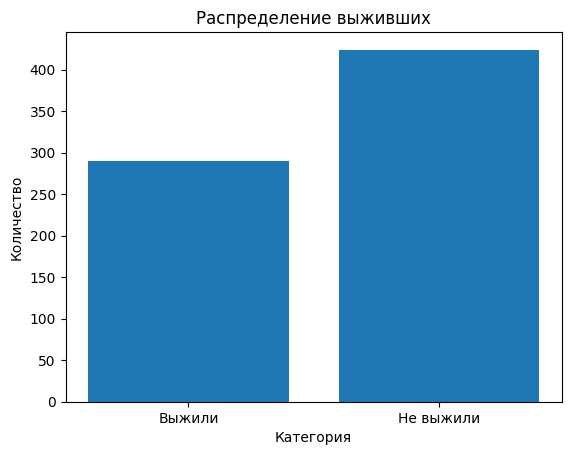

In [35]:
count = df['Survived'].value_counts()
survived = count.get(1, 0)
not_survived = count.get(0, 0)

labels = ['Выжили', 'Не выжили']
sizes = [survived, not_survived]

fig, ax = plt.subplots()
ax.bar(x=labels, height=sizes)
ax.set_title('Распределение выживших')
ax.set_xlabel('Категория')
ax.set_ylabel('Количество')
plt.show()

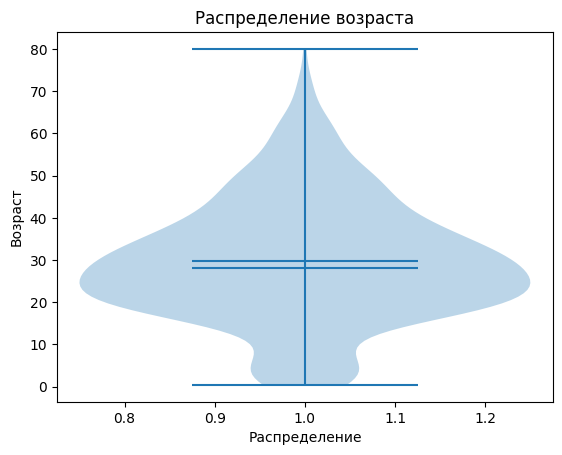

In [25]:
df['Age']= pd.to_numeric(df['Age'], errors='coerce')
df =df.dropna(subset=['Age'])

age = df['Age']

fig, ax = plt.subplots()
ax.violinplot(age, showmeans=True, showmedians=True)
ax.set_title('Распределение возраста')
ax.set_xlabel('Распределение')
ax.set_ylabel('Возраст')
plt.show()

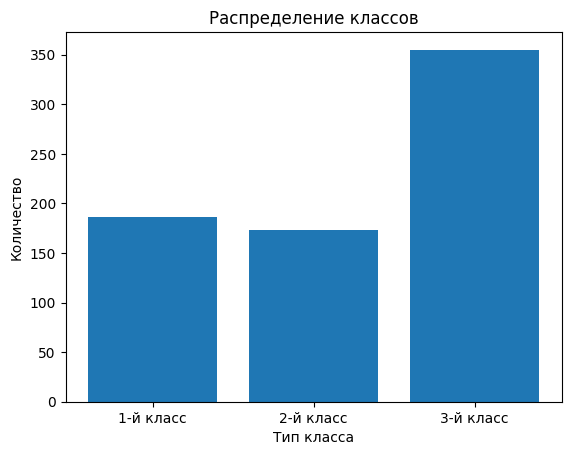

In [26]:
count = df['Pclass'].value_counts()
Class1 = count.get(1, 0)
Class2 = count.get(2, 0)
Class3 = count.get(3, 0)

x = ['1-й класс', '2-й класс',"3-й класс"]
y = [Class1,Class2,Class3]

fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_title('Распределение классов')
ax.set_xlabel('Тип класса')
ax.set_ylabel('Количество')
plt.show()

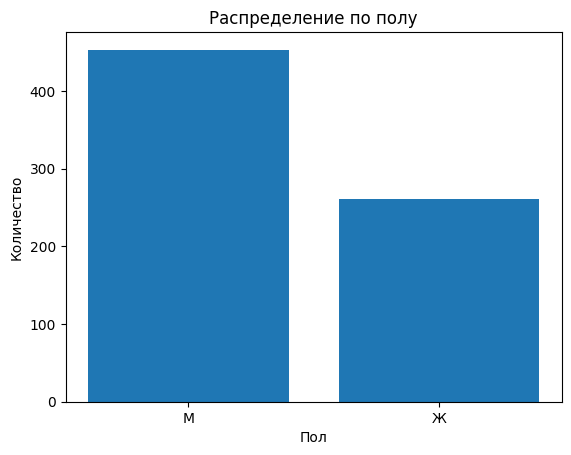

In [27]:
count = df['Sex'].value_counts()
male = count.get('male', 0)
female = count.get('female', 0)

labels = ['М', 'Ж']
sizes = [male,female]

fig, ax = plt.subplots()
ax.bar(x=labels, height=sizes)
ax.set_title('Распределение по полу')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество')
plt.show()

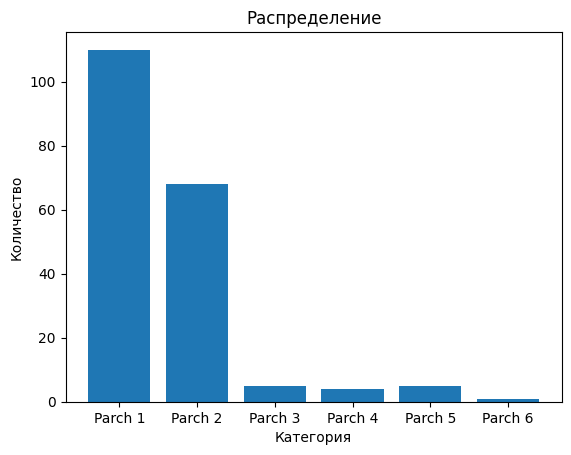

In [28]:
count = df['Parch'].value_counts()
P1 = count.get(1, 0)
P2 = count.get(2, 0)
P3 = count.get(3, 0)
P4 = count.get(4, 0)
P5 = count.get(5, 0)
P6 = count.get(6, 0)

x = ['Parch 1', 'Parch 2',"Parch 3","Parch 4","Parch 5","Parch 6"]
y = [P1,P2,P3,P4,P5,P6]

fig, ax = plt.subplots()
ax.bar(x=x, height=y)
ax.set_title('Распределение')
ax.set_xlabel('Категория')
ax.set_ylabel('Количество')
plt.show()

график типа boxplot для столбца Age

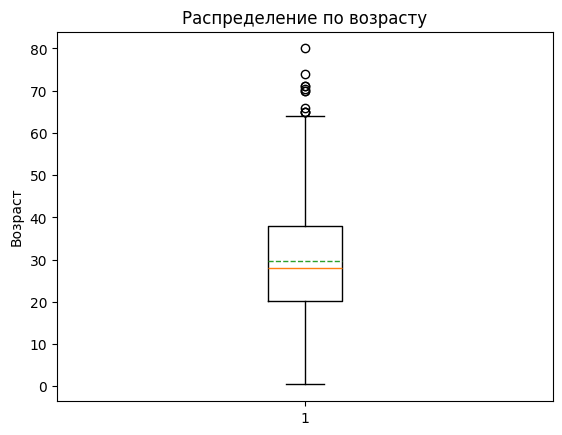

In [29]:
df['Age']= pd.to_numeric(df['Age'], errors='coerce')
df =df.dropna(subset=['Age'])

age = df['Age']
fig, ax = plt.subplots()
ax.boxplot(age, showmeans=True, meanline=True)
ax.set_title('Распределение по возрасту')
ax.set_ylabel('Возраст')
plt.show()

Возраст от 0 до ~65 лет, медиана 28-29 лет, средний возраст 30-31 год. Основная часть данных находится в диапазоне от 21 года до 39 лет (получается, что бОльшая часть - это молодежь). Есть выбросы со значениями выше 65 лет.

Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах

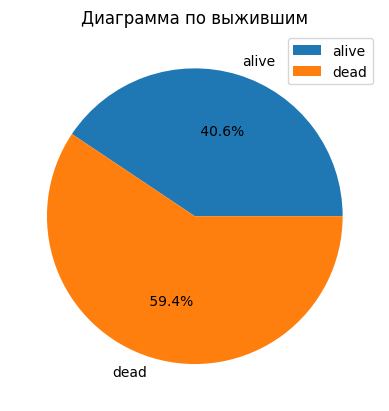

In [33]:
count = df['Survived'].value_counts()
alive = count.get(1, 0)
dead = count.get(0, 0)

labels = ['alive', 'dead']
sizes = [alive,dead]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct= ' %1.1f%%')
ax.set_title('Диаграмма по выжившим')
ax.legend()
plt.show()

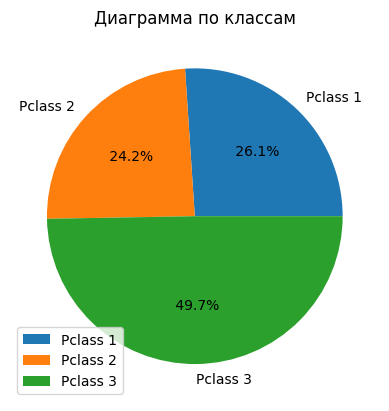

In [34]:
count = df['Pclass'].value_counts()
P1 = count.get(1, 0)
P2 = count.get(2, 0)
P3 = count.get(3, 0)


labels = ['Pclass 1', 'Pclass 2','Pclass 3']
sizes = [P1,P2,P3]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct= ' %1.1f%%')
ax.set_title('Диаграмма по классам')
ax.legend()

Постройте график типа pairplot для всех числовых переменных датасета

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

NameError: name 'plt' is not defined

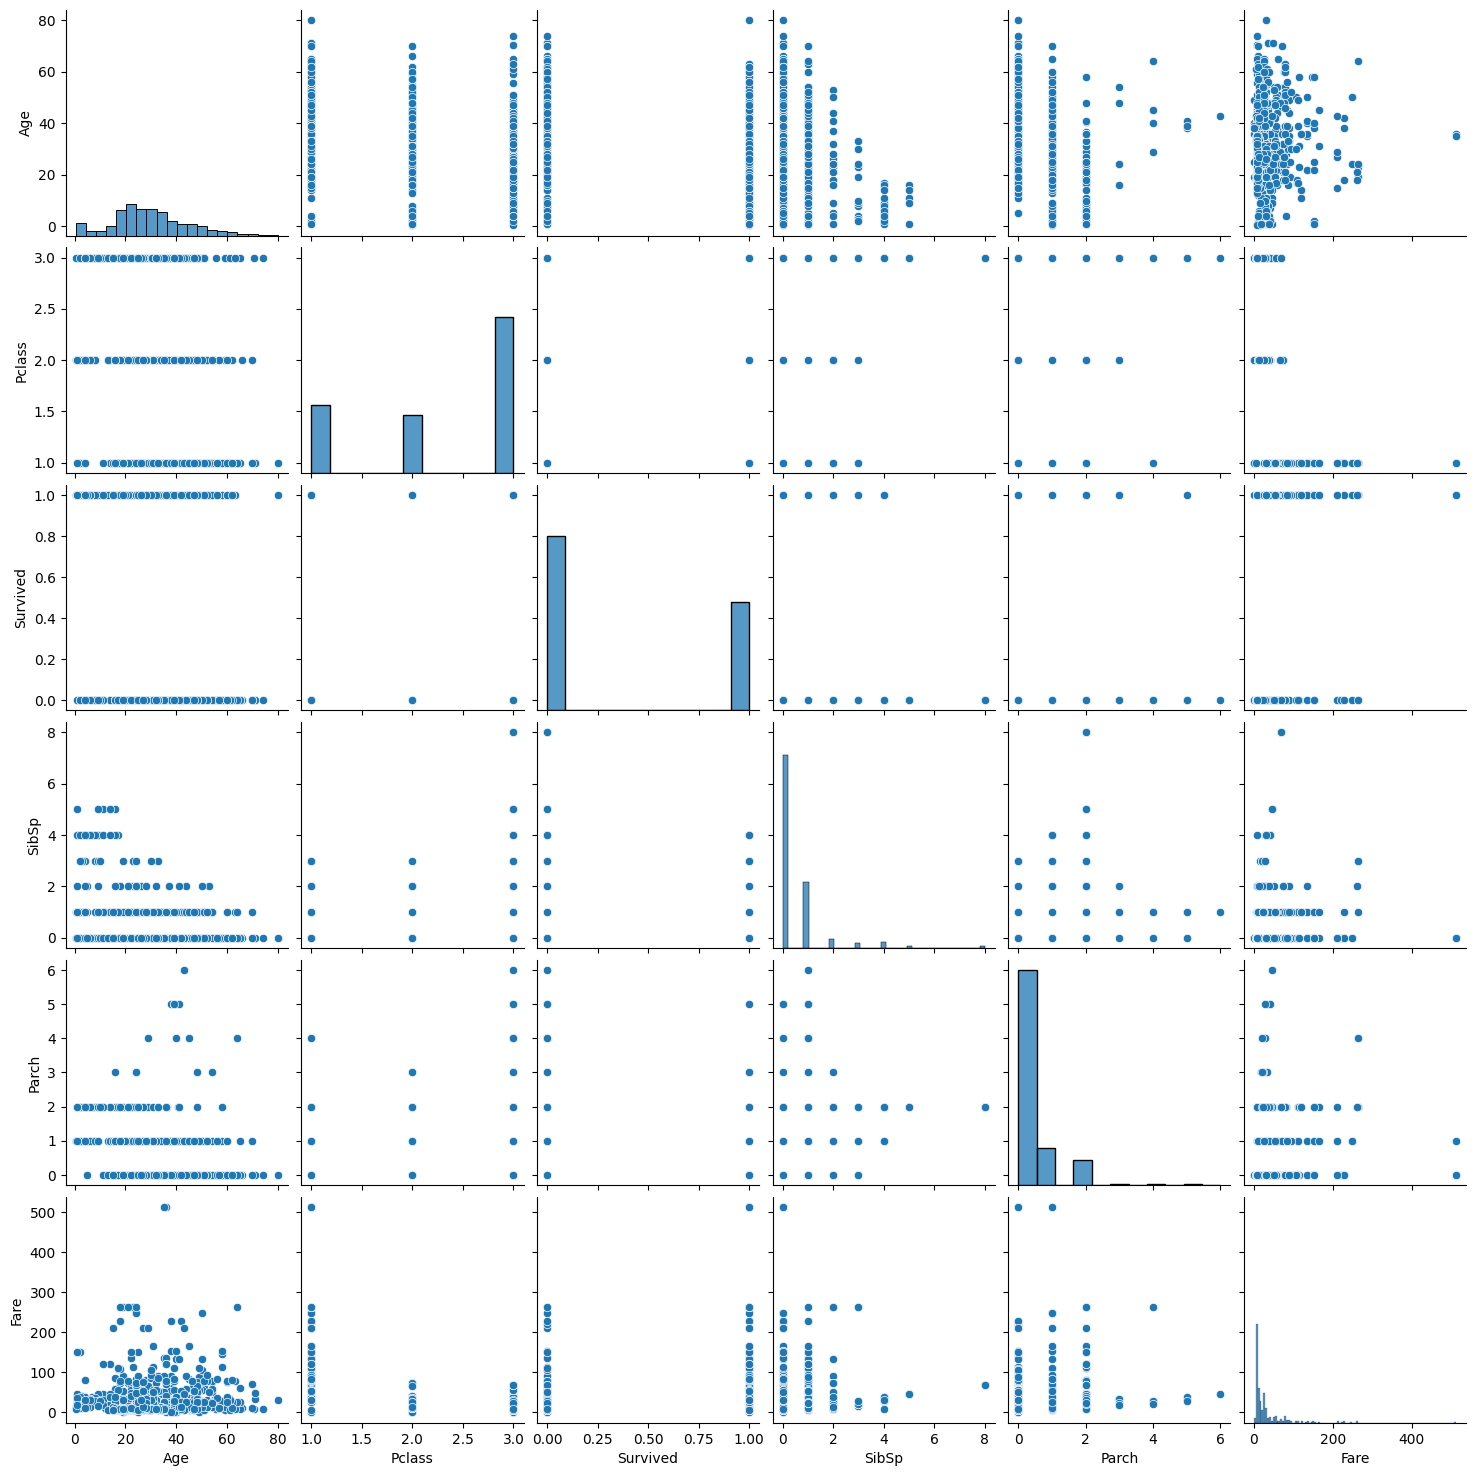

In [7]:
df = pd.read_csv('train.csv')
columns = ['Age','Pclass','Survived','SibSp','Parch','Fare']
sns.pairplot(df[columns])
plt.show()

Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе

In [18]:
grouped =df.groupby(['Pclass','Sex']).size().reset_index(name='cnt')
fig = px.sunburst(
    grouped,
    path=['Pclass','Sex'],
    values='cnt',
    title = 'Распределение пассажиров'
)
fig.show()